In [1]:
# General
import numpy as np

# Qiskit imports
from qiskit import QuantumCircuit,  ClassicalRegister, QuantumRegister
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Qiskit Runtime imports
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator

# Plotting routines
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile
from qiskit import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit.transpiler.passes import ALAPScheduleAnalysis
from qiskit.transpiler import PassManager
from qiskit import schedule
import csv


In [4]:
## Save your IBM Quantum account and set it as your default account.
QiskitRuntimeService.save_account(

    channel="ibm_quantum",

    token="a4943c84731880e342eba28d155effd22be7ed8dc1a4fd3c92e7b0fa557af26413a572539aaa5fa7928f57803a3a415d4bc04c28d441ff4ea1a4abd3fe779764",

    set_as_default=True,

    # Use `overwrite=True` if you're updating your token.
    overwrite=True,
)
service = QiskitRuntimeService(channel="ibm_quantum")
backend = service.backend("ibm_sherbrooke")
backend.name

'ibm_sherbrooke'

In [3]:
backend_properties = backend.properties()

qubits_of_interest = range(6)

# Iterate over the specified qubits
for qubit in qubits_of_interest:
    # Retrieve qubit properties
    qubit_props = backend_properties.qubits[qubit]
    
    # Extract T1 and T2 times
    t1 = next(prop.value for prop in qubit_props if prop.name == 'T1')
    t2 = next(prop.value for prop in qubit_props if prop.name == 'T2')
    
    # Retrieve gate properties for single-qubit gates
    for gate in backend_properties.gates:
        if gate.qubits == [qubit]:
            gate_name = gate.gate
            gate_error = next((param.value for param in gate.parameters if param.name == 'gate_error'), None)
            gate_length = next((param.value for param in gate.parameters if param.name == 'gate_length'), None)
            print(f"Qubit {qubit}: Gate {gate_name} - Error: {gate_error}, Duration: {gate_length} seconds")
    
    # Retrieve readout error
    readout_error = backend_properties.readout_error(qubit)
    # print T1 T2 and readout error
    # print(f"Qubit {qubit}: T1 = {t1} µs, T2 = {t2} µs, Readout Error: {readout_error}\n")

# Gate error 
target = backend.target
gate_name = 'ecr'  # Replace with the desired gate name

if gate_name in target:
    for qargs, props in target[gate_name].items():
        if props is not None:
            error_rate = props.error
            print(f"Gate: {gate_name}, Qubits: {qargs}, Error Rate: {error_rate}")
        else:
            print(f"Gate: {gate_name}, Qubits: {qargs}, Error Rate: Not available")
else:
    print(f"Gate {gate_name} is not supported on this backend.")


# id gate
print("=== ID Gate Duration and Error ===")
if "id" in target:
    # 'id' is typically a single-qubit gate, so keys are likely (0,), (1,), etc.
    for qubit_tuple, props in target["id"].items():
        if props is not None:
            duration = props.duration
            error = props.error
            print(f"Qubit(s) {qubit_tuple}: duration = {duration} s, error = {error}")

Qubit 0: Gate id - Error: 0.0040634065850736764, Duration: 56.888888888888886 seconds
Qubit 0: Gate rz - Error: 0, Duration: 0 seconds
Qubit 0: Gate sx - Error: 0.0040634065850736764, Duration: 56.888888888888886 seconds
Qubit 0: Gate x - Error: 0.0040634065850736764, Duration: 56.888888888888886 seconds
Qubit 0: Gate reset - Error: None, Duration: 1272.888888888889 seconds
Qubit 1: Gate id - Error: 0.00020128017643137547, Duration: 56.888888888888886 seconds
Qubit 1: Gate rz - Error: 0, Duration: 0 seconds
Qubit 1: Gate sx - Error: 0.00020128017643137547, Duration: 56.888888888888886 seconds
Qubit 1: Gate x - Error: 0.00020128017643137547, Duration: 56.888888888888886 seconds
Qubit 1: Gate reset - Error: None, Duration: 1272.888888888889 seconds
Qubit 2: Gate id - Error: 0.00018040238414901213, Duration: 56.888888888888886 seconds
Qubit 2: Gate rz - Error: 0, Duration: 0 seconds
Qubit 2: Gate sx - Error: 0.00018040238414901213, Duration: 56.888888888888886 seconds
Qubit 2: Gate x - Er

In [4]:
# scot qreg 
def phase_code(backend):
    qreg = QuantumRegister(5, 'q')
    creg = ClassicalRegister(5, 'c')

    qc = QuantumCircuit(qreg, creg)


    qc.h(qreg[3])
    qc.h(qreg[4])
    qc.cx(qreg[0], qreg[1])
    qc.cx(qreg[0], qreg[2])

    qc.h(qreg[0])
    qc.h(qreg[1])
    qc.h(qreg[2])

    qc.cx(qreg[3], qreg[0])
    qc.cx(qreg[3], qreg[1])
    qc.cx(qreg[4], qreg[1])
    qc.cx(qreg[4], qreg[2])


    qc.barrier()
    qc.h(qreg[0])
    qc.h(qreg[1])
    qc.h(qreg[2])
    qc.h(qreg[3])
    qc.h(qreg[4])

    qc.barrier()
    for i in range(5):
        qc.measure(i, i)
    
    display (qc.draw('mpl'))

    pass_manager = generate_preset_pass_manager(
    optimization_level=3, backend=backend,initial_layout= [0,1,2,3,4] )
    transpiled_qc1 = pass_manager.run(qc)
    # display( transpiled_qc1.draw("mpl") )
    
    return transpiled_qc1

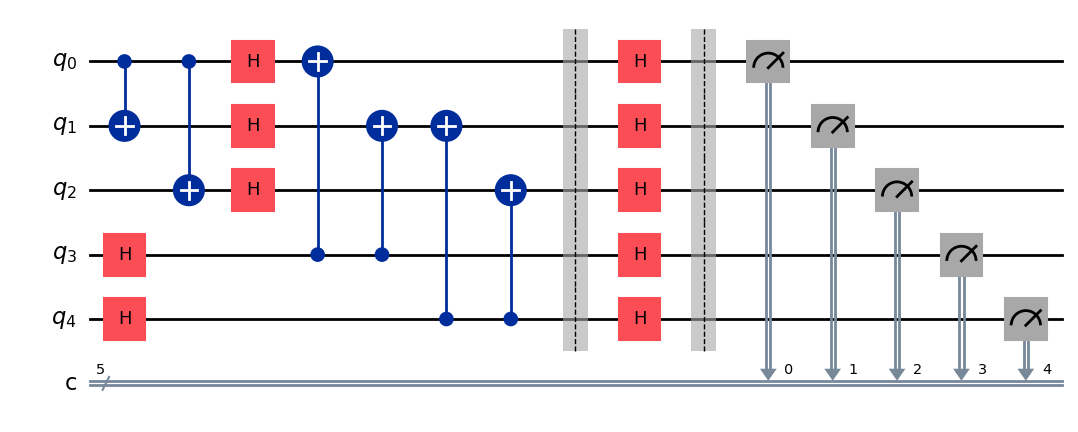

In [5]:
transpiledQc = phase_code(backend)

In [7]:
sampler = Sampler(mode=backend)

for i in range(3):
    job = sampler.run([transpiledQc], shots=10000)
    print("Job ID:", job.job_id())

Job ID: czpkeqjqnmvg008thwrg
Job ID: czpkerknhqag008s6tkg
Job ID: czpkesbd8drg008gbxs0


In [8]:
def id_gates_5(backend, num_gates):
    qcId = QuantumCircuit(5)
    for i in range(num_gates):
        for j in range(5):
            qcId.id(j)
            qcId.barrier(j)
    qcId.measure_all()
    pass_manager = generate_preset_pass_manager(
    optimization_level=0, backend=backend,
     initial_layout= [ 0,1,2,3,4] )
    transpiled_qc1 = pass_manager.run(qcId)
    #display( transpiled_qc1.draw("mpl"))
    return transpiled_qc1

In [9]:
qc3 = id_gates_5(backend, num_gates = 189)

In [7]:
def getExecTime(num_iter, qc):
    exec_time = 0
    for c in range(num_iter):
    
        scheduled_circuit = schedule(qc, backend=backend)
        circuit_duration = scheduled_circuit.duration * backend.configuration().dt    
        exec_time += circuit_duration*1000*1000*1000

    print("execution time    {:}[ns]".format(exec_time/num_iter))

In [10]:
getExecTime(10, qc3) # baseline
getExecTime(10, transpiledQc)

execution time    11968.0[ns]
execution time    11840.0[ns]


In [6]:
sampler = Sampler(mode=backend)

for i in range(3):
    job = sampler.run([qc3], shots=10000)
    print("Job ID:", job.job_id())

NameError: name 'qc3' is not defined

In [ ]:
def get_and_save_job_results(job_id, filename="job_results.csv"):
    """
    Retrieves results from an IBM Quantum job and saves them to a CSV file.

    Args:
        job_id (str): The ID of the IBM Quantum job.
        filename (str): The name of the CSV file to save the results to.
    """
    try:
        retrieved_job = service.job(job_id)
        retrieved_job.result()
        result = retrieved_job.result()[0] # get the first result.
        counts = result.join_data().get_counts()

        with open(filename, "a", newline="") as csvfile:
            writer = csv.writer(csvfile)

            # Check if the file is empty and write the header if it is.
            if csvfile.tell() == 0:
                writer.writerow(["Job ID", "State", "Count"])

            writer.writerow([job_id]) #write the job id
            for state, count in counts.items():
                writer.writerow([state, count])

        print(f"Results for job ID '{job_id}' saved to '{filename}'")

    except Exception as e:
        print(f"An error occurred: {e}")

In [7]:
get_and_save_job_results("czgpt3rhrmy000842m30", "phase_results_corrected.csv")

Results for job ID 'czgpt3rhrmy000842m30' saved to 'phase_results_corrected.csv'


In [ ]:
def process_and_plot(csv_file):
    # Load CSV file, ignoring job ID rows
    data = []
    with open(csv_file, 'r') as file:
        for line in file:
            parts = line.strip().split(',')
            if len(parts) == 2:
                data.append(parts)
    
    df = pd.DataFrame(data, columns=["State", "Count"])
    df["Count"] = pd.to_numeric(df["Count"])
    
    # Compute median values per state
    median_counts = df.groupby("State")["Count"].median()
    
    # Extract reference state 00000 and all other states
    ref_value = median_counts.get("00000", 0)
    other_states = median_counts.drop("00000", errors='ignore')
    
    # Print summed numerical comparison
    comparison_sum = (other_states).sum()
    print("Number of non 00000 incorrect states:", comparison_sum)
    print("Number of 00000, correct states:", ref_value)
    print("Error percentage:",  comparison_sum / 10000 * 100, "%")

    # Plot the data
    plt.figure(figsize=(12, 6))
    median_counts.sort_values().plot(kind="bar", color="skyblue", edgecolor="black")
    plt.xlabel("State")
    plt.ylabel("Median Count")
    plt.title("Median Count of Values per State")
    plt.xticks(rotation=90)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

Number of non 00000 incorrect states: 1126.0
Number of 00000, correct states: 8865.0
Error percentage: 11.26 %


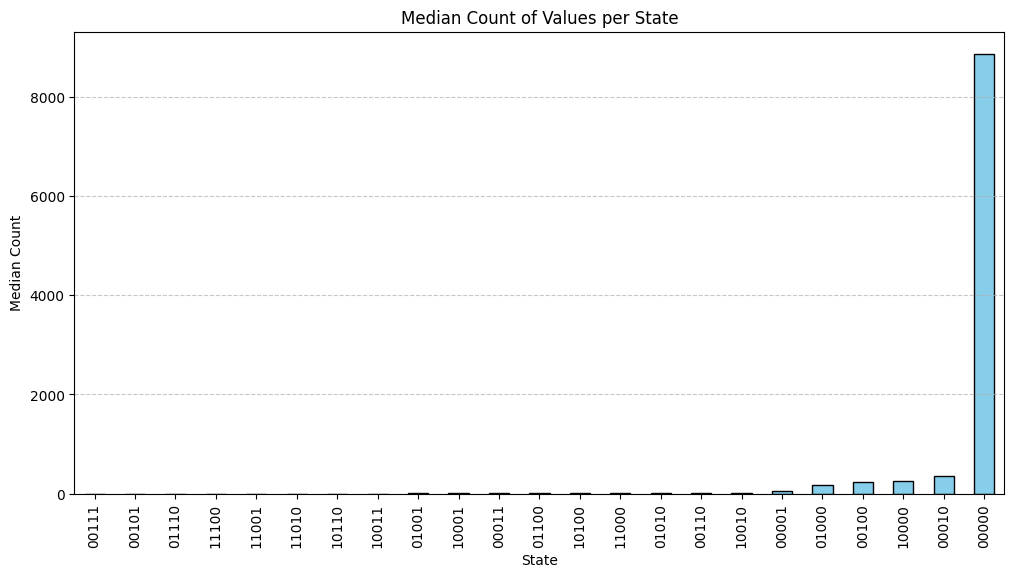

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
csv_filename = "phase_results_baseline.csv"  # Replace with the actual CSV filename
process_and_plot(csv_filename)

In [11]:
def process_and_plot_corrected(csv_file):
    # Load CSV file, ignoring job ID rows
    data = []
    with open(csv_file, 'r') as file:
        for line in file:
            parts = line.strip().split(',')
            if len(parts) == 2:
                data.append(parts)
    
    df = pd.DataFrame(data, columns=["State", "Count"])
    df["Count"] = pd.to_numeric(df["Count"])
    
    # Compute median values per state
    median_counts = df.groupby("State")["Count"].median()
    
    # Extract reference state 00000 and all other states
    ref_value = median_counts.get("00000", 0)
    ref_value += median_counts.get("10100", 0)
    ref_value += median_counts.get("01001", 0)
    ref_value += median_counts.get("11010", 0)
    other_states = median_counts.drop("00000", errors='ignore')
    other_states = other_states.drop("10100", errors='ignore')
    other_states = other_states.drop("01001", errors='ignore')
    other_states = other_states.drop("11010", errors='ignore')


    # Print summed numerical comparison
    comparison_sum = (other_states).sum()
    print("Number of non 00000 incorrect states:", comparison_sum)
    print("Number of 00000, correct states:", ref_value)
    print("Error percentage:",  comparison_sum / 10000 * 100, "%")

    # Plot the data
    plt.figure(figsize=(12, 6))
    median_counts.sort_values().plot(kind="bar", color="skyblue", edgecolor="black")
    plt.xlabel("State")
    plt.ylabel("Median Count")
    plt.title("Median Count of Values per State")
    plt.xticks(rotation=90)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

Number of non 00000 incorrect states: 4068.0
Number of 00000, correct states: 5918.0
Error percentage: 40.68 %


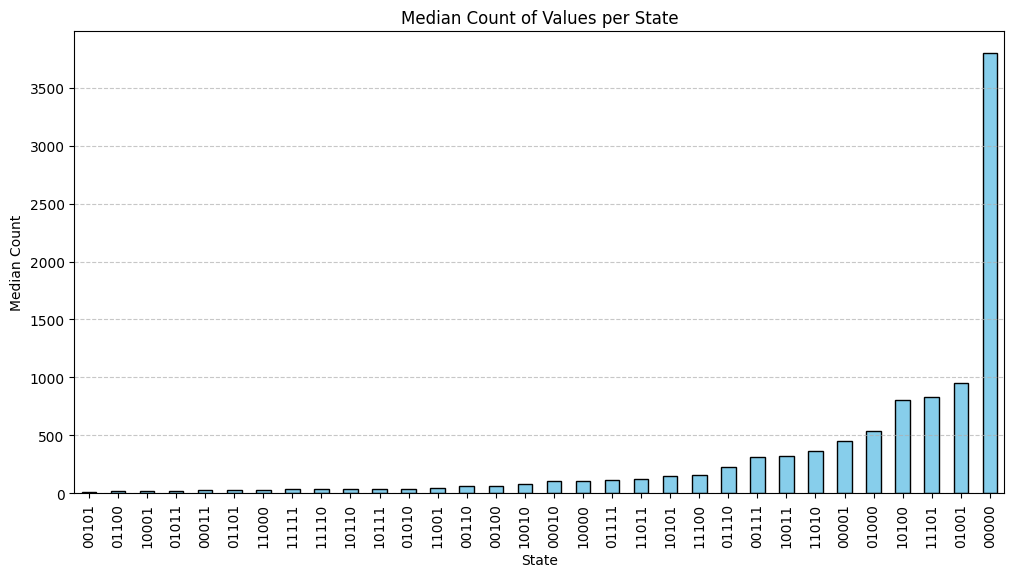

In [12]:
import pandas as pd
csv_filename = "phase_results_corrected.csv"  # Replace with the actual CSV filename
process_and_plot_corrected(csv_filename)